# Temporal-Difference Methods

In this notebook, you will write your own implementations of many Temporal-Difference (TD) methods.

While we have provided some starter code, you are welcome to erase these hints and write your code from scratch.

---

### Part 0: Explore CliffWalkingEnv

We begin by importing the necessary packages.

In [1]:
import sys
import gymnasium as gym
import numpy as np
import random
import math
from collections import defaultdict, deque
import matplotlib.pyplot as plt
%matplotlib inline

import check_test
from plot_utils import plot_values, plot_policy

Use the code cell below to create an instance of the [CliffWalking](https://github.com/openai/gym/blob/master/gym/envs/toy_text/cliffwalking.py) environment.

In [2]:
env = gym.make('CliffWalking-v1')

The agent moves through a $4\times 12$ gridworld, with states numbered as follows:
```
[[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
 [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
 [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35],
 [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]]
```
At the start of any episode, state `36` is the initial state.  State `47` is the only terminal state, and the cliff corresponds to states `37` through `46`.

The agent has 4 potential actions:
```
UP = 0
RIGHT = 1
DOWN = 2
LEFT = 3
```

Thus, $\mathcal{S}^+=\{0, 1, \ldots, 47\}$, and $\mathcal{A} =\{0, 1, 2, 3\}$.  Verify this by running the code cell below.

In [3]:
print(env.action_space)
print(env.observation_space)

Discrete(4)
Discrete(48)


In this mini-project, we will build towards finding the optimal policy for the CliffWalking environment.  The optimal state-value function is visualized below.  Please take the time now to make sure that you understand _why_ this is the optimal state-value function.

_**Note**: You can safely ignore the values of the cliff "states" as these are not true states from which the agent can make decisions.  For the cliff "states", the state-value function is not well-defined._

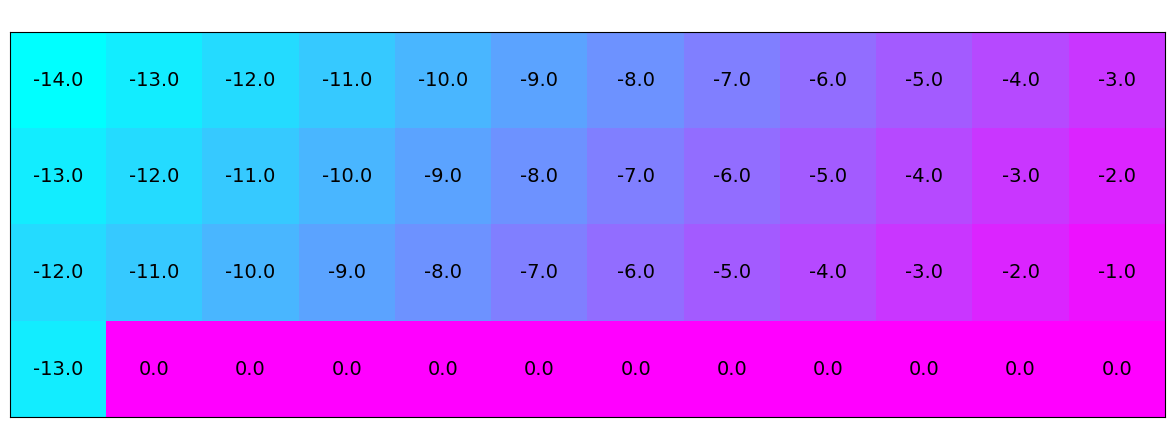

In [4]:
# define the optimal state-value function
V_opt = np.zeros((4,12))
V_opt[0:13][0] = -np.arange(3, 15)[::-1]
V_opt[0:13][1] = -np.arange(3, 15)[::-1] + 1
V_opt[0:13][2] = -np.arange(3, 15)[::-1] + 2
V_opt[3][0] = -13

plot_values(V_opt, (4,12), (15,5))

### Part 1: TD Control: Sarsa

In this section, you will write your own implementation of the Sarsa control algorithm.

Your algorithm has four arguments:
- `env`: This is an instance of an OpenAI Gym environment.
- `num_episodes`: This is the number of episodes that are generated through agent-environment interaction.
- `alpha`: This is the step-size parameter for the update step.
- `gamma`: This is the discount rate.  It must be a value between 0 and 1, inclusive (default value: `1`).

The algorithm returns as output:
- `Q`: This is a dictionary (of one-dimensional arrays) where `Q[s][a]` is the estimated action value corresponding to state `s` and action `a`.

Please complete the function in the code cell below.

(_Feel free to define additional functions to help you to organize your code._)

$Q(S,A) = Q(S,A)+(1/N)(R_{t+1}+\gamma Q(S_{t+1},A_{t+1})-Q(S_{t},A_{t}))$

In [5]:
def sarsaUpdate(Q, alpha, gamma, s, a, r, sN=None, aN=None):
    Q_saN = Q[sN][aN] if sN is not None else 0
    newVal = Q[s][a] + alpha*(r+gamma*Q_saN-Q[s][a])
    return newVal

def epsilonGreedy(Q, state, epsilon):
    if random.random() > epsilon:
        return np.argmax(Q[state])
    else:
        return random.choice(np.arange(env.action_space.n))

In [6]:
def sarsa(env, num_episodes, alpha, gamma=1.0):
    # initialize action-value function (empty dictionary of arrays)
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    # initialize performance monitor
    # loop over episodes
    for i_episode in range(1, num_episodes+1):
        # monitor progress
        if i_episode % 100 == 0:
            print("\rEpisode {}/{}".format(i_episode, num_episodes), end="")
            sys.stdout.flush()   

        edone = False
        eps = 1.0/i_episode
        state, info = env.reset()
        action = epsilonGreedy(Q, state, eps)

        while not edone:
            sN, r, done, info, prob = env.step(action)

            if not done:
                aN = epsilonGreedy(Q, sN, eps)
                Q[state][action] = sarsaUpdate(Q, alpha, gamma, state, action, r, sN, aN)
                state = sN
                action = aN
            else:
                Q[state][action] = sarsaUpdate(Q, alpha, gamma, state, action, r)
                edone = True
    env.close()
    return Q

Use the next code cell to visualize the **_estimated_** optimal policy and the corresponding state-value function.  

If the code cell returns **PASSED**, then you have implemented the function correctly!  Feel free to change the `num_episodes` and `alpha` parameters that are supplied to the function.  However, if you'd like to ensure the accuracy of the unit test, please do not change the value of `gamma` from the default.

Episode 5000/5000

**<span style="color: red;">PLEASE TRY AGAIN</span>**

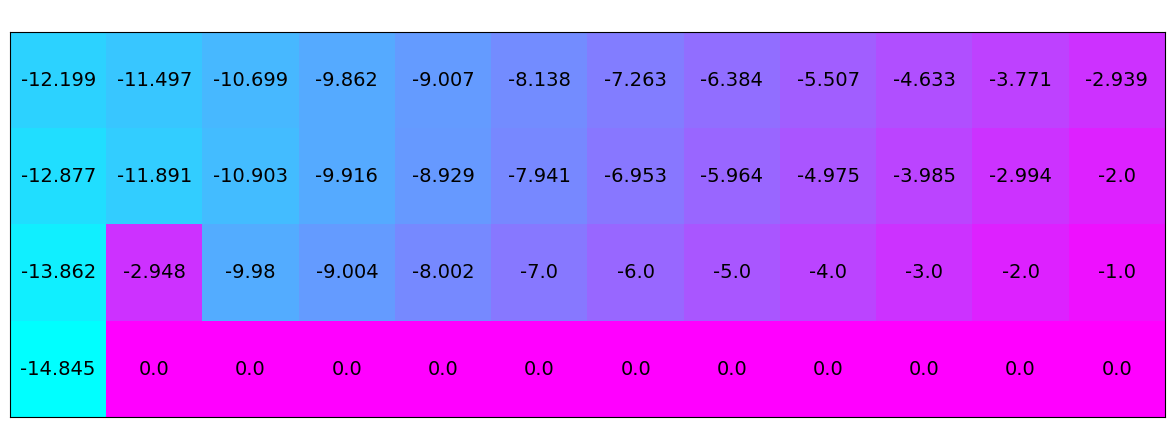


Estimated Optimal Policy (UP = 0, RIGHT = 1, DOWN = 2, LEFT = 3, N/A = -1):
[[ 0  1  1  1  1  1  3  1  1  1  2  2]
 [ 1  1  1  1  1  1  1  2  1  1  2  2]
 [ 0  0  1  1  1  1  1  1  1  1  1  2]
 [ 0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]]


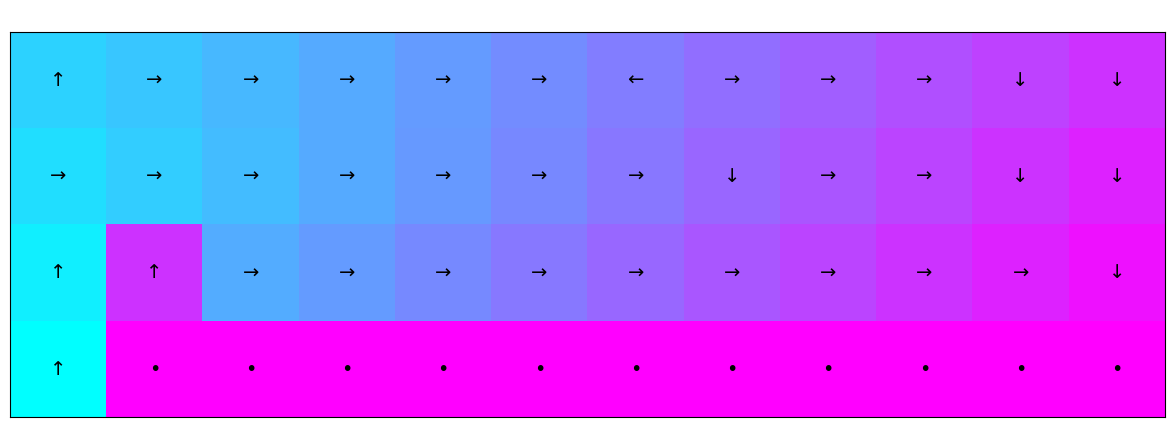

In [7]:
# obtain the estimated optimal policy and corresponding action-value function
Q_sarsa = sarsa(env, 5000, .01)

# print the estimated optimal policy
policy_sarsa = np.array([np.argmax(Q_sarsa[key]) if key in Q_sarsa else -1 for key in np.arange(48)]).reshape(4,12)
check_test.run_check('td_control_check', policy_sarsa)

# plot the estimated optimal state-value function
V_sarsa = ([np.max(Q_sarsa[key]) if key in Q_sarsa else 0 for key in np.arange(48)])
plot_values(V_sarsa, size=(4,12), im_size=(15,5))
print("\nEstimated Optimal Policy (UP = 0, RIGHT = 1, DOWN = 2, LEFT = 3, N/A = -1):")
print(policy_sarsa)

plot_policy(V_sarsa, policy_sarsa, (4,12), (15,5))

### Part 2: TD Control: Q-learning

In this section, you will write your own implementation of the Q-learning control algorithm.

Your algorithm has four arguments:
- `env`: This is an instance of an OpenAI Gym environment.
- `num_episodes`: This is the number of episodes that are generated through agent-environment interaction.
- `alpha`: This is the step-size parameter for the update step.
- `gamma`: This is the discount rate.  It must be a value between 0 and 1, inclusive (default value: `1`).

The algorithm returns as output:
- `Q`: This is a dictionary (of one-dimensional arrays) where `Q[s][a]` is the estimated action value corresponding to state `s` and action `a`.

Please complete the function in the code cell below.

(_Feel free to define additional functions to help you to organize your code._)

$Q(S,A) = Q(S,A)+(1/N)(R_{t+1}+\gamma\,\underset{A'}{\max} Q(S_{t+1},A')-Q(S_{t},A_{t}))$

In [8]:
def qL_update(Q, alpha, gamma, s, a, r, sN=None):
    Q_saN = Q[sN][np.argmax(Q[s])] if sN is not None else 0
    newQVal = Q[s][a] + alpha*(r+gamma*Q_saN-Q[s][a])
    return newQVal
def epsilonGreedyQ(Q, state, epsilon):
    if random.random() > epsilon:
        return np.argmax(Q[state])
    else:
        return random.choice(np.arange(env.action_space.n))

In [9]:
def q_learning(env, num_episodes, alpha, gamma=1.0):
    # initialize empty dictionary of arrays
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    # loop over episodes
    for i_episode in range(1, num_episodes+1):
        # monitor progress
        if i_episode % 100 == 0:
            print("\rEpisode {}/{}".format(i_episode, num_episodes), end="")
            sys.stdout.flush()
        
        eps = 1/i_episode
        edone = False
        s, info = env.reset()
        a = epsilonGreedyQ(Q, s, eps)

        while edone is not True:
            sN, r, done, info, prob = env.step(a)

            if not done:
                Q[s][a] = qL_update(Q,alpha,gamma,s,a,r,sN)
                s = sN
                a = epsilonGreedyQ(Q, s, eps)
            else:
                Q[s][a] = qL_update(Q,alpha,gamma,s,a,r)
                edone = True
    env.close()
    return Q

Use the next code cell to visualize the **_estimated_** optimal policy and the corresponding state-value function. 

If the code cell returns **PASSED**, then you have implemented the function correctly!  Feel free to change the `num_episodes` and `alpha` parameters that are supplied to the function.  However, if you'd like to ensure the accuracy of the unit test, please do not change the value of `gamma` from the default.

Episode 5000/5000

**<span style="color: green;">PASSED</span>**

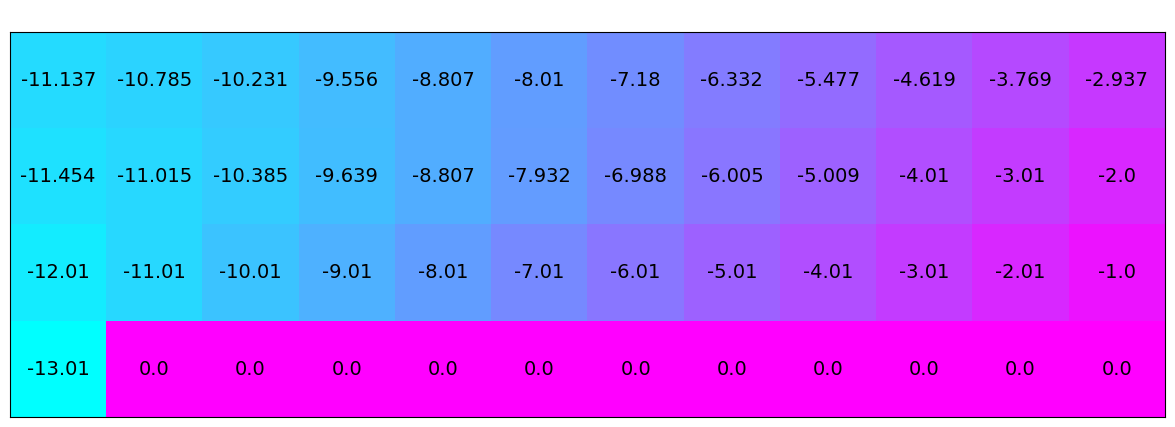


Estimated Optimal Policy (UP = 0, RIGHT = 1, DOWN = 2, LEFT = 3, N/A = -1):
[[ 0  2  3  1  1  1  0  1  1  0  1  2]
 [ 1  1  1  1  1  1  1  1  1  1  1  2]
 [ 1  1  1  1  1  1  1  1  1  1  1  2]
 [ 0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]]


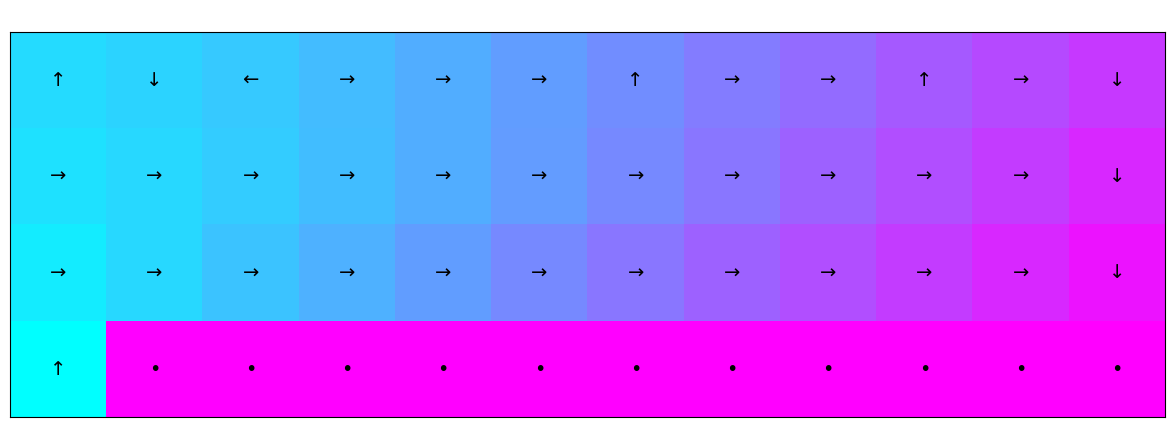

In [10]:
# obtain the estimated optimal policy and corresponding action-value function
Q_sarsamax = q_learning(env, 5000, .01)

# print the estimated optimal policy
policy_sarsamax = np.array([np.argmax(Q_sarsamax[key]) if key in Q_sarsamax else -1 for key in np.arange(48)]).reshape((4,12))
check_test.run_check('td_control_check', policy_sarsamax)

# plot the estimated optimal state-value function
V_sarsamax = ([np.max(Q_sarsamax[key]) if key in Q_sarsamax else 0 for key in np.arange(48)])
plot_values(V_sarsamax, (4,12), (15,5))
print("\nEstimated Optimal Policy (UP = 0, RIGHT = 1, DOWN = 2, LEFT = 3, N/A = -1):")
print(policy_sarsamax)

plot_policy(V_sarsamax, policy_sarsamax, (4,12), (15,5))

### Part 3: TD Control: Expected Sarsa

In this section, you will write your own implementation of the Expected Sarsa control algorithm.

Your algorithm has four arguments:
- `env`: This is an instance of an OpenAI Gym environment.
- `num_episodes`: This is the number of episodes that are generated through agent-environment interaction.
- `alpha`: This is the step-size parameter for the update step.
- `gamma`: This is the discount rate.  It must be a value between 0 and 1, inclusive (default value: `1`).

The algorithm returns as output:
- `Q`: This is a dictionary (of one-dimensional arrays) where `Q[s][a]` is the estimated action value corresponding to state `s` and action `a`.

Please complete the function in the code cell below.

(_Feel free to define additional functions to help you to organize your code._)

In [26]:
def eSarsaUpdate(Q, alpha, gamma, eps, s, a, r, sN=None):
    if sN is not None:
        expectedQ = 0
        aMax = np.argmax(Q[sN])
        for i in range(len(Q[sN])):
            if i != aMax:
                expectedQ += (eps/len(Q[sN]))*Q[sN][i]
            else:
                expectedQ += (1-eps+eps/len(Q[sN]))*Q[sN][i]
        Q_saN = expectedQ
    else:
        Q_saN = 0

    newVal = Q[s][a] + alpha*(r+gamma*Q_saN-Q[s][a])
    return newVal

def epsilonGreedyE(Q, state, epsilon):
    if random.random() > epsilon:
        return np.argmax(Q[state])
    else:
        return random.choice(np.arange(env.action_space.n))

In [27]:
def expected_sarsa(env, num_episodes, alpha, gamma=1.0):
    # initialize empty dictionary of arrays
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    # loop over episodes
    for i_episode in range(1, num_episodes+1):
        # monitor progress
        if i_episode % 100 == 0:
            print("\rEpisode {}/{}".format(i_episode, num_episodes), end="")
            sys.stdout.flush()
        
        edone = False
        eps = 1.0/i_episode
        state, info = env.reset()
        action = epsilonGreedyE(Q, state, eps)

        while not edone:
            sN, r, done, info, prob = env.step(action)
            if not done:
                aN = epsilonGreedyE(Q, sN, eps)
                Q[state][action] = eSarsaUpdate(Q, alpha, gamma, eps, state, action, r, sN)
                state = sN
                action = aN
            else:
                Q[state][action] = eSarsaUpdate(Q, alpha, gamma, eps, state, action, r)
                edone = True
    env.close()
    return Q

Use the next code cell to visualize the **_estimated_** optimal policy and the corresponding state-value function.  

If the code cell returns **PASSED**, then you have implemented the function correctly!  Feel free to change the `num_episodes` and `alpha` parameters that are supplied to the function.  However, if you'd like to ensure the accuracy of the unit test, please do not change the value of `gamma` from the default.

Episode 5000/5000

**<span style="color: green;">PASSED</span>**

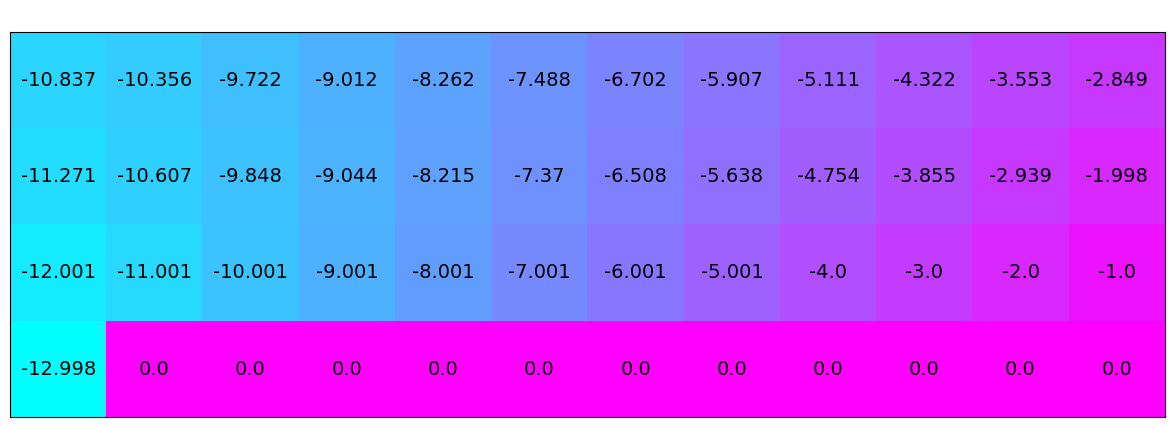


Estimated Optimal Policy (UP = 0, RIGHT = 1, DOWN = 2, LEFT = 3, N/A = -1):
[[ 1  0  3  1  1  1  1  1  2  0  2  2]
 [ 3  0  1  0  0  1  2  1  1  1  1  2]
 [ 1  1  1  1  1  1  1  1  1  1  1  2]
 [ 0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]]


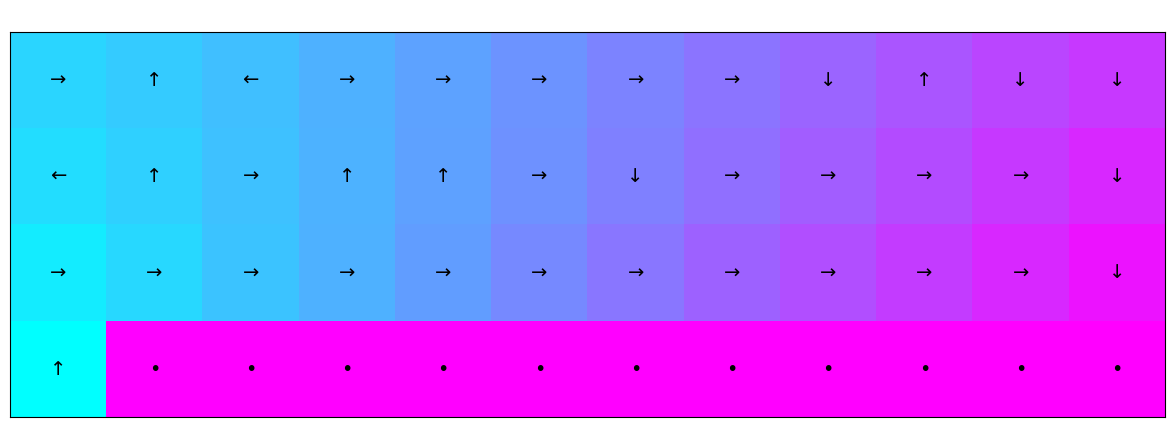

In [35]:
# obtain the estimated optimal policy and corresponding action-value function
Q_expsarsa = expected_sarsa(env, 5000, 0.0075)

# print the estimated optimal policy
policy_expsarsa = np.array([np.argmax(Q_expsarsa[key]) if key in Q_expsarsa else -1 for key in np.arange(48)]).reshape(4,12)
check_test.run_check('td_control_check', policy_expsarsa)

# plot the estimated optimal state-value function
V_expsarsa = ([np.max(Q_expsarsa[key]) if key in Q_expsarsa else 0 for key in np.arange(48)])
plot_values(V_expsarsa, (4,12), (15,5))
print("\nEstimated Optimal Policy (UP = 0, RIGHT = 1, DOWN = 2, LEFT = 3, N/A = -1):")
print(policy_expsarsa)

plot_policy(V_expsarsa, policy_expsarsa, (4,12), (15,5))